## 1. Exploratory Data Analysis (EDA)

In [47]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print(pd.__version__)

3.0.5


In [2]:
# Load data

filepath = "../data/raw/dataset_original.csv"
df = pd.read_csv(filepath)

In [3]:
df.head()

,station_ID,location,date,tavg,tmin,tmax
0,108,seoul,01/10/1907,13.5,7.9,20.7
1,108,seoul,02/10/1907,16.2,7.9,22.0
2,108,seoul,03/10/1907,16.2,13.1,21.3
3,108,seoul,04/10/1907,16.5,11.2,22.0
4,108,seoul,05/10/1907,17.6,10.9,25.4


In [4]:
df.tail()

,station_ID,location,date,tavg,tmin,tmax
42231,108,seoul,15/08/2026,26.1,25.1,29.5
42232,108,seoul,16/08/2026,24.1,22.6,25.5
42233,108,seoul,17/08/2026,24.9,23.7,26.0
42234,108,seoul,18/08/2026,27.0,23.9,31.5
42235,108,seoul,19/08/2026,27.1,24.7,30.1


### 1.1. 데이터 기본 정보 확인

In [5]:
df.shape # data size

(42236, 6)

In [6]:
df.columns

Index(['station_ID', 'location', 'date', 'tavg', 'tmin', 'tmax'], dtype='str')

In [7]:
df.info() # data type or df.dtypes

<class 'pandas.DataFrame'>
RangeIndex: 42236 entries, 0 to 42235
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   station_ID  42236 non-null  int64  
 1   location    42236 non-null  str    
 2   date        42236 non-null  str    
 3   tavg        42236 non-null  float64
 4   tmin        42234 non-null  float64
 5   tmax        42234 non-null  float64
dtypes: float64(3), int64(1), str(2)
memory usage: 2.5 MB


In [8]:
df.describe() # 통계 정보 stat info (only numerical values)

# print(df[["tavg", "tmax", "tmin"]].describe())
# Mean, standard deviation, minimum, maximum, quartiles, etc.

,station_ID,tavg,tmin,tmax
count,42236.0,42236.000000,42234.000000,42234.000000
mean,108.0,11.856317,7.573957,16.850983
std,0.0,10.674639,10.905265,10.979455
min,108.0,-19.200000,-23.100000,-16.300000
25%,108.0,2.800000,-1.300000,7.400000
50%,108.0,13.100000,8.200000,18.700000
75%,108.0,21.300000,17.200000,26.300000
max,108.0,33.700000,30.300000,39.600000


In [9]:
df.isnull().sum()   # 결측치; missing value
                    # tmin와 tmax에 결측치 두 개씩 있음을 확인

station_ID    0
location      0
date          0
tavg          0
tmin          2
tmax          2
dtype: int64

In [10]:
df.duplicated().sum()   # 중복 데이터 없음

np.int64(0)

### 1.2. 시각화 (Visualization)

Visualization before modifying the raw data.

#### 1.2.1. 일일 기온 (Daily temperature time series)

* Understand the overall structure and extreme values.

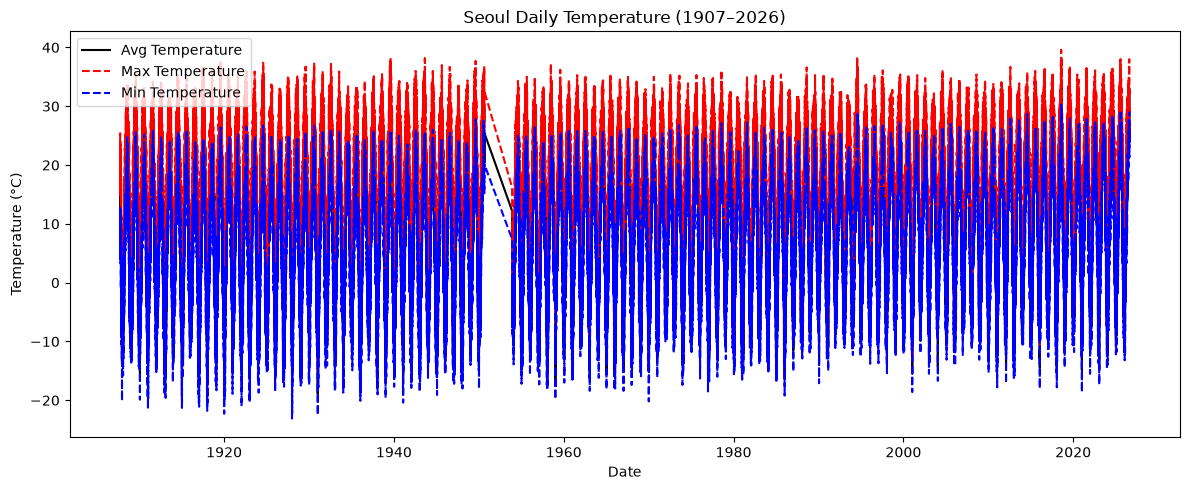

In [ ]:
df["date"] = pd.to_datetime(df["date"], format="%d/%m/%Y")  # 날짜가 str이므로 그래프에 검게 마크처리된 것 처럼 나와서 여기서 일단 변환
plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["tavg"], color="black", label="Avg Temperature")
plt.plot(df["date"], df["tmax"], 'r--', label="Max Temperature")
plt.plot(df["date"], df["tmin"], 'b--', label="Min Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.title("Seoul Daily Temperature (1907–2026)")
plt.legend(loc=2)
plt.tight_layout()
plt.show()


#### 1.2.2. 온도 분포 (Temperature distributions)

* Understand the distributions and potential extreme values.
* 온도 분포는 Bimodal distribution (이중 모드 분포) 형태를 보임: 대략적으로 추운 계절과 따뜻한 계절에 해당하는 두 개의  봉우리 존재. 서울에 겨울과 여름 사이에 계절 변화가 뚜렷하기 때문에 예상되는 결과.

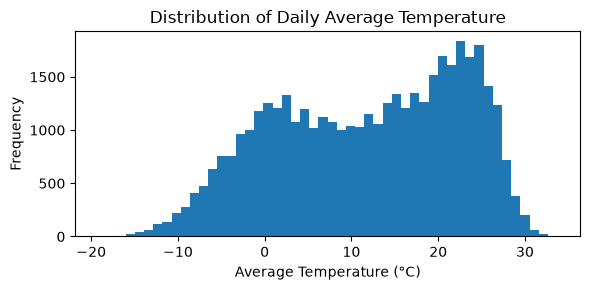

In [13]:
plt.figure(figsize=(6, 3))
plt.hist(df["tavg"].dropna(), bins=50)
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Frequency")
plt.title("Distribution of Daily Average Temperature")
plt.tight_layout()
plt.show()

#### 1.2.3. 최저 온도와 최고 온도의 산점도 (Min vs Max temperature scatter plot)

* Check the relationship between daily minimum and maximum temperatures.
* Identify potentially unusual observations.
* 너무 낮은 최저온도에 아주 높은 최고온도(또는 반대)를 가지는 날의 data point 는 없었음. 이상치 없는 듯함.

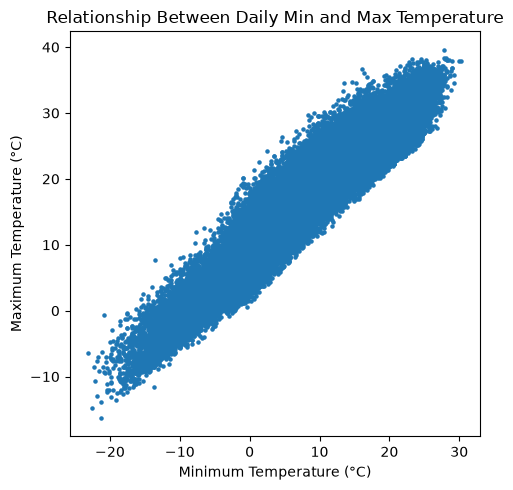

In [41]:
plt.figure(figsize=(5, 5))
plt.scatter(df["tmin"], df["tmax"], s=5)
plt.xlabel("Minimum Temperature (°C)")
plt.ylabel("Maximum Temperature (°C)")
plt.title("Relationship Between Daily Min and Max Temperature")
plt.tight_layout()
plt.show()

## 2. 데이터 전처리 (Data Preprocessing)

### 2.1. 데이터 클리닝 (Data Cleaning)

* 결측치 Missing values
* 중복 데이터 행 / 날짜 Duplicate rows / dates
* 날짜 검사 / 날짜 형식 변환 Date validation/conversion
* 이상치 탐지 Outlier detection

#### 2.1.1. 결측치 (Missing values)

In [14]:
print("-" * 20)
print("변수당 결측치 개수")
print("-" * 20)
print(df.isnull().sum())    # 결측치 몇 개있는지 확인
print("-" * 20)
print("결측치 위치")
print("-" * 20)
print(df[df["tmin"].isnull() | df["tmax"].isnull()])    # tmax와 tmin에 결측치 있다고 나왔으므로 이 두 변수만 확인

# alternative:
# missing = df[df[["tmin", "tmax", "tavg"]].isnull().any(axis=1)]
# print(missing[["date", "tmin", "tmax", "tavg"]])

--------------------
변수당 결측치 개수
--------------------
station_ID    0
location      0
date          0
tavg          0
tmin          2
tmax          2
dtype: int64
--------------------
결측치 위치
--------------------
       station_ID location        date  tavg  tmin  tmax
20504         108    seoul  19/02/1967  -1.7   NaN   NaN
39002         108    seoul  12/10/2017  11.4   8.8   NaN
40763         108    seoul  08/08/2022  26.8   NaN  28.4


* 결측치 있음을 확인하였고 NaN로 놔두기로 결정. 결측치를 임의의 값으로 채우면 실제 관측되지 않은 기온을 만들어내어 장기적인 기온 추세와 분석 결과를 왜곡할 수 있기 때문.

#### 2.1.2. 중복 데이터 (Duplicates)

* 중복 데이터 없음 확인:

In [15]:
print("Duplicate rows:", df.duplicated().sum())             # 모든 column에 중복 데이터 유무 확인
print("Duplicate dates:", df["date"].duplicated().sum())    # 날짜에 중복 데이터 유무 확인

# duplicate_dates = df[df["date"].duplicated(keep=False)]   # 필요시 사용

Duplicate rows: 0
Duplicate dates: 0


#### 2.1.3. 날짜 처리 (Date handling)

In [12]:
print(df["date"].dtype)     # 데이터 타입이 str인 것을 확인

str


In [14]:
# 모든 날짜가 'dd/mm/yyyy' 를 따르는지 확인: 0을 반환하면 모든 날짜는 dd/mm/yyyy 형식을 따른다고 해석 가능.

date_check = pd.to_datetime(
    df["date"],
    format="%d/%m/%Y",
    errors="coerce"
)
print("Invalid date values:", date_check.isna().sum())

Invalid date values: 0


In [18]:
# 필요한 경우 아래 실행
print(df.loc[date_check.isna(), "date"])

Series([], Name: date, dtype: str)


In [ ]:
# 변환
df["date"] = pd.to_datetime(df["date"], format="%d/%m/%Y")

In [16]:
print(df["date"].dtype)

datetime64[us]


In [18]:
# Check the date range
print("Start date:", df["date"].min())
print("End date:", df["date"].max())

Start date: 1907-10-01 00:00:00
End date: 2026-08-19 00:00:00


In [19]:
# Check whether the dates are sorted:
print("Dates sorted:", df["date"].is_monotonic_increasing)

# If not sorted, use:
# df = df.sort_values("date").reset_index(drop=True)

Dates sorted: True


필요할 경우(sorted 아닌 경우) 실행:

```python
df = df.sort_values("date").reset_index(drop=True)
```

#### 2.1.4. 이상치 탐지 (Outlier Detection)

* Detect → Investigate → Decide 따름
* 여기서는 만약 100나 -100도가 나온다면 관측이 잘못된 값이라고 여겨져서 제거하겠지만, 
* IQR방법을 사용했을 경우 (아래 (2) IQR 계산 참고), 서울에서 일평균온도 -24.95 ~ 49.05℃ 구간, 일최저온도 -29.05 ~ 44.95℃ 구간, 일최고온도 -20.95 ~ 54.65℃ 구간 밖에서는 이상치의 범위에 들어감. 하지만 실제 극한 기상 현상이고 오류가 아니기에 제거하지 않을 것.

##### (1) 산점도 (Scatter plot) 

* extrem values를 시각적으로 볼 수는 있지만, 시각적 검사만으로는 이상치를 탐지하기에 충분하지 않았음.

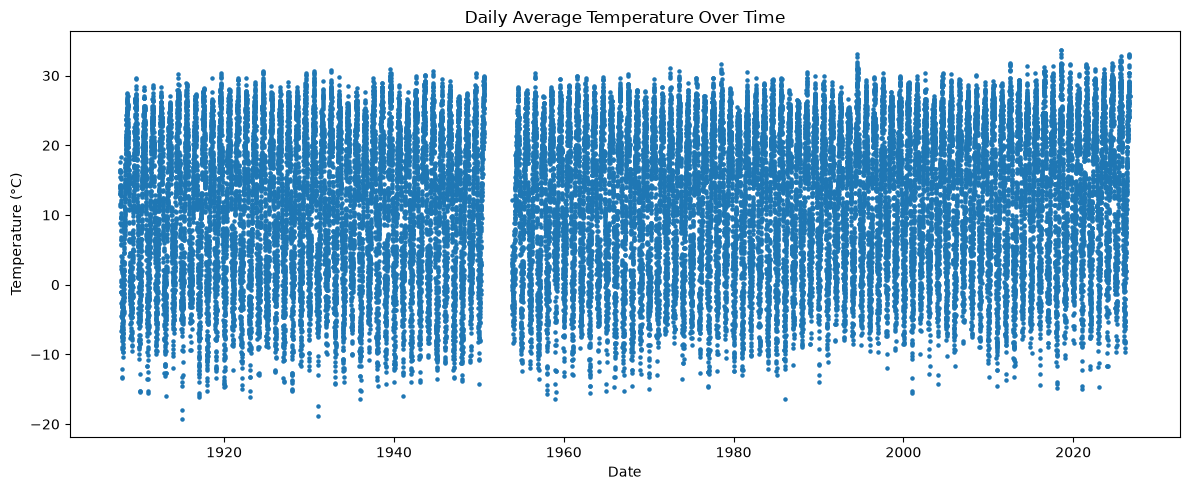

In [22]:
# Daily Average Temperature Over Time

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.scatter(df["date"], df["tavg"], s=5, label="Average Temperature")
plt.title("Daily Average Temperature Over Time")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.tight_layout()
plt.show()

* 일평균 온도의 구간의 우상향 관찰 가능.

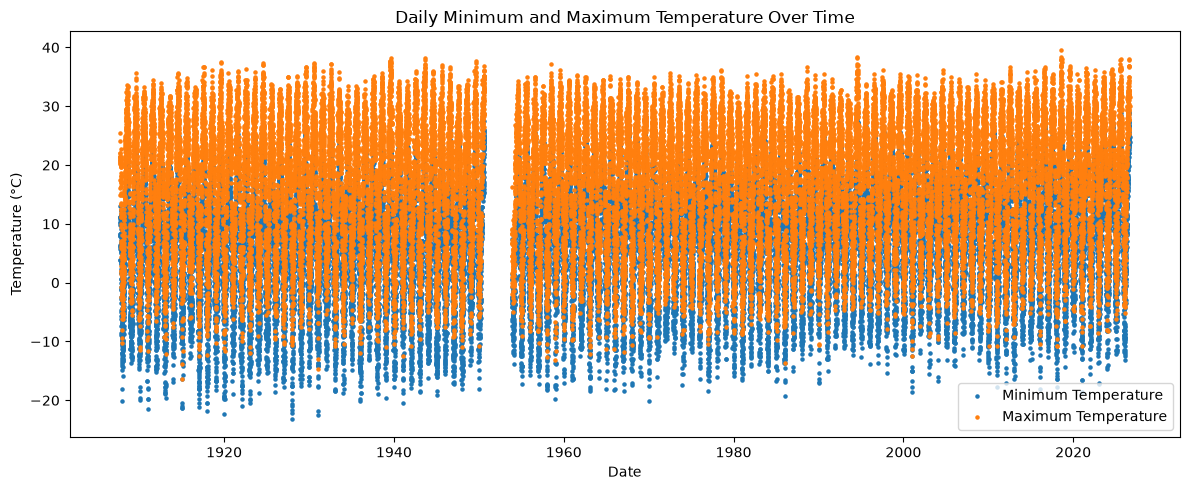

In [24]:
# Daily Minimum and Maximum Temperature Over Time

plt.figure(figsize=(12, 5))

plt.scatter(df["date"], df["tmin"], s=5, label="Minimum Temperature")
plt.scatter(df["date"], df["tmax"], s=5, label="Maximum Temperature")

plt.title("Daily Minimum and Maximum Temperature Over Time")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()

plt.tight_layout()
plt.show()

* 일최저기온의 우상향이 관찰되며 (약 -20°C → -15°C), 일최고기온-일최저기온의 구간이 좁아지고 있는 것을 시각적으로 확인. 즉, 이는 지난 100년간 겨울철 최저기온의 상승을 의미함.

##### (2) 사분위 범위 Interquartile Range (IQR)

* 통계적으로 unusual values를 식별.

In [23]:
def find_iqr_outliers(df, column):
    q1 = df[column].quantile(0.25)  # Finds the number where 25% of the data points are <= that value.
    q3 = df[column].quantile(0.75)  # Finds the number where 75% of the data points are <= that value.

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr    # 숫자 1.5는 분포의 99.3% 에 해당하는 영역을 확보하기 위함
    upper_bound = q3 + 1.5 * iqr

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    print(f"\n{column}")
    print(f"Q1: {q1:.2f}")
    print(f"Q3: {q3:.2f}")
    print(f"IQR: {iqr:.2f}")
    print(f"Lower bound: {lower_bound:.2f}")
    print(f"Upper bound: {upper_bound:.2f}")
    print(f"Number of outliers: {len(outliers)}")

    return outliers


tavg_outliers = find_iqr_outliers(df, "tavg")
tmin_outliers = find_iqr_outliers(df, "tmin")
tmax_outliers = find_iqr_outliers(df, "tmax")

# 이상치 없음을 확인


tavg
Q1: 2.80
Q3: 21.30
IQR: 18.50
Lower bound: -24.95
Upper bound: 49.05
Number of outliers: 0

tmin
Q1: -1.30
Q3: 17.20
IQR: 18.50
Lower bound: -29.05
Upper bound: 44.95
Number of outliers: 0

tmax
Q1: 7.40
Q3: 26.30
IQR: 18.90
Lower bound: -20.95
Upper bound: 54.65
Number of outliers: 0


In [24]:
# 위에서 이미 이상치 없음을 확인하였지만 있다면 아래 실행하여 확인

print(tavg_outliers[["date", "tavg"]])
print(tmin_outliers[["date", "tmin"]])
print(tmax_outliers[["date", "tmax"]])

Empty DataFrame
Columns: [date, tavg]
Index: []
Empty DataFrame
Columns: [date, tmin]
Index: []
Empty DataFrame
Columns: [date, tmax]
Index: []


##### (3) Box plot

* Compare ranges, medians, and potential outliers.
* 시각적으로, 박스플롯에는 선 위나 아래에 독립적인 점 표시가 없음. 이는 관측된 최소값과 최대값이 $[Q_1 - 1.5 \times \text{IQR},\ Q_3 + 1.5 \times \text{IQR}]$ 경계 범위 내에 있음을 확인시켜주며, 데이터 세트에 통계적 이상치가 없음을 입증함.

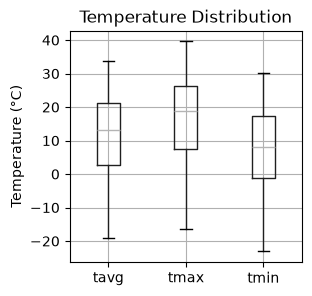

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(3,3))
df.boxplot(column=["tavg", "tmax", "tmin"])
plt.ylabel("Temperature (°C)")
plt.title("Temperature Distribution")
plt.show()

#### 2.1.5. 필요없는 columns 제거

In [25]:
# 108과 seoul만 있음을 확인:
print(df["station_ID"].unique())
print(df["location"].unique())

[108]
<ArrowStringArray>
['seoul']
Length: 1, dtype: str


In [26]:
df = df.drop(columns=["station_ID", "location"])
print(df.columns)

Index(['date', 'tavg', 'tmin', 'tmax'], dtype='str')


#### 2.1.6. Cleaning 요약

결과적으로 Data Cleaning에서는 날짜 형식 변환과 필요없는 columns을 제거하였음.

In [27]:
print("\n=== Data Cleaning Summary ===")

print("Number of rows:", len(df))
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate dates:", df["date"].duplicated().sum())

print("\nDate range:")
print(df["date"].min(), "~", df["date"].max())


=== Data Cleaning Summary ===
Number of rows: 42236
Missing values:
date    0
tavg    0
tmin    2
tmax    2
dtype: int64

Duplicate rows: 0
Duplicate dates: 0

Date range:
1907-10-01 00:00:00 ~ 2026-08-19 00:00:00


### 2.2. 데이터 변환 (Data Transformation)

#### 2.2.1. 현재 데이터셋 확인

In [28]:
print(df.head())
print("-" * 20)
print(df.dtypes)

        date  tavg  tmin  tmax
0 1907-10-01  13.5   7.9  20.7
1 1907-10-02  16.2   7.9  22.0
2 1907-10-03  16.2  13.1  21.3
3 1907-10-04  16.5  11.2  22.0
4 1907-10-05  17.6  10.9  25.4
--------------------
date    datetime64[us]
tavg           float64
tmin           float64
tmax           float64
dtype: object


#### 2.2.2. year, month, day, day_of_year 생성

In [29]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["day_of_year"] = df["date"].dt.dayofyear     # Jan 1 → 1; Jan 2 → 2; Feb 1 → 32

print(df.head())

        date  tavg  tmin  tmax  year  month  day  day_of_year
0 1907-10-01  13.5   7.9  20.7  1907     10    1          274
1 1907-10-02  16.2   7.9  22.0  1907     10    2          275
2 1907-10-03  16.2  13.1  21.3  1907     10    3          276
3 1907-10-04  16.5  11.2  22.0  1907     10    4          277
4 1907-10-05  17.6  10.9  25.4  1907     10    5          278


In [30]:
df.dtypes

date           datetime64[us]
tavg                  float64
tmin                  float64
tmax                  float64
year                    int32
month                   int32
day                     int32
day_of_year             int32
dtype: object

#### 2.2.3. season 생성

* Spring: March–May
* Summer: June–August
* Autumn: September–November
* Winter: December–February

In [31]:
def get_season(month):
    if month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    elif month in [9, 10, 11]:
        return "Autumn"
    else:
        return "Winter"

df["season"] = df["month"].apply(get_season)


## alternative:

# season_map = {
#     1: "Winter",
#     2: "Winter",
#     3: "Spring",
#     4: "Spring",
#     5: "Spring",
#     6: "Summer",
#     7: "Summer",
#     8: "Summer",
#     9: "Autumn",
#     10: "Autumn",
#     11: "Autumn",
#     12: "Winter"
# }

# df["season"] = df["month"].map(season_map)

In [32]:
df[["date", "month", "season"]].head()

,date,month,season
0,1907-10-01,10,Autumn
1,1907-10-02,10,Autumn
2,1907-10-03,10,Autumn
3,1907-10-04,10,Autumn
4,1907-10-05,10,Autumn


#### 2.2.4. 온도 기반 indicator 생성

* 생성된 indicators (온도 기준은 달라질 수 있음):
    * `summer_like`: 평균온도 >= 20°C
    * `winter_like`: 평균온도 <= 5°C
    * `warm_day`: 25°C <= 최고온도 < 30°C
    * `hot_day`: 30°C <= 최고온도 < 35°C
    * `over_35`: 최고온도 >= 35°C
    * `cold_day`: 최고온도 <= 10°C & 최저온도 < 0°C
    * 참고로 `warm_day`, `hot_day`, `cold_day`는 추후 사용 가능성을 대비해 생성되었고 실제 분석에는 사용되지 않음.

* 여기서 `summer_like`와 `winter_like` 자체가 "계절이 확장되었다"는 것을 의미하는 것은 아니고 각 날짜가 기온 기준을 만족하는지를 나타내는 indicator임.
    * "5월과 9월이 점점 여름처럼 변하고 있는가?"
    * "11월과 3월이 덜 겨울처럼 변하고 있는가?"
    * 따라서 서울의 날씨는 4계절에서 여름/겨울의 두 계절로 변하고 있는가?
    * 에 대한 답변은 Analysis 단계에서 year + month별 `summer_like`와 `winter_like` 비율을 계산하고 추세를 분석해서 답할 것임.

In [33]:
# === Create temperature-based season indicators ===
# Summer-like day:
# KMA seasonal criterion: daily average temperature >= 20°C
df["summer_like"] = (df["tavg"] >= 20).astype(int)

# Winter-like day:
# KMA seasonal criterion: daily average temperature <= 5°C
df["winter_like"] = (df["tavg"] <= 5).astype(int)


# === Create warm/hot/extreme heat indicators ===
# Warm day: 25 <= tmax < 30
df["warm_day"] = ((df["tmax"] >= 25) & (df["tmax"] < 30)).astype(int)

# Hot day: 30 <= tmax < 35
df["hot_day"] = ((df["tmax"] >= 30) & (df["tmax"] < 35)).astype(int)

# Extreme heat day: tmax >= 35
df["over_35"] = (df["tmax"] >= 35).astype(int)


# === Create cold-weather indicator ===
# Cold day:
# tmax <= 10°C AND tmin < 0°C
df["cold_day"] = ((df["tmax"] <= 10) & (df["tmin"] < 0)).astype(int)

참고) 데이터 분석시에 아래 사용해서 여름/겨울 확장하고 있는지 체크:

```python
monthly_season = (
    df.groupby(["year", "month"])
      .agg(
          summer_like_ratio=("summer_like", "mean"),
          winter_like_ratio=("winter_like", "mean")
      )
      .reset_index()
)
```

```text
year   month   summer_like_ratio
1907     5          0.02
1908     5          0.04
...
2024     5          0.61
2025     5          0.65
```

#### 2.2.5. 변환된 데이터 확인

In [34]:
print("\n=== Transformed Data ===")
print(df.head())

print("\n=== Data Types ===")
print(df.dtypes)

print("\n=== Columns ===")
print(df.columns.tolist())


=== Transformed Data ===
        date  tavg  tmin  tmax  year  month  day  day_of_year  season  \
0 1907-10-01  13.5   7.9  20.7  1907     10    1          274  Autumn   
1 1907-10-02  16.2   7.9  22.0  1907     10    2          275  Autumn   
2 1907-10-03  16.2  13.1  21.3  1907     10    3          276  Autumn   
3 1907-10-04  16.5  11.2  22.0  1907     10    4          277  Autumn   
4 1907-10-05  17.6  10.9  25.4  1907     10    5          278  Autumn   

   summer_like  winter_like  warm_day  hot_day  over_35  cold_day  
0            0            0         0        0        0         0  
1            0            0         0        0        0         0  
2            0            0         0        0        0         0  
3            0            0         0        0        0         0  
4            0            0         1        0        0         0  

=== Data Types ===
date           datetime64[us]
tavg                  float64
tmin                  float64
tmax             

#### 2.2.6. 데이터 유효성 검사

In [35]:
print("\n=== Seasons ===")
print(df["season"].unique())

print("\n=== Year Range ===")
print(df["year"].min(), "~", df["year"].max())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Temperature Indicator Counts ===")

print("Summer-like days:", df["summer_like"].sum())
print("Winter-like days:", df["winter_like"].sum())
print("Warm days (Tmax >= 25°C):", df["warm_day"].sum())
print("Hot days (Tmax >= 30°C):", df["hot_day"].sum())
print("Extreme heat days (Tmax > 35°C):", df["over_35"].sum())
print("Cold days:", df["cold_day"].sum())


=== Seasons ===
<ArrowStringArray>
['Autumn', 'Winter', 'Spring', 'Summer']
Length: 4, dtype: str

=== Year Range ===
1907 ~ 2026

=== Missing Values ===
date           0
tavg           0
tmin           2
tmax           2
year           0
month          0
day            0
day_of_year    0
season         0
summer_like    0
winter_like    0
warm_day       0
hot_day        0
over_35        0
cold_day       0
dtype: int64

=== Temperature Indicator Counts ===
Summer-like days: 12664
Winter-like days: 13042
Warm days (Tmax >= 25°C): 8568
Hot days (Tmax >= 30°C): 4084
Extreme heat days (Tmax > 35°C): 315
Cold days: 11250


#### 2.2.7. 처리된 데이터 저장

In [ ]:
df.to_csv(
    "../data/processed/dataset_processed.csv",
    index=False,
    encoding="utf-8-sig"
)

Remarks:
* utf-8: Saves the file in standard UTF-8 encoding. It does not include a Byte Order Mark (BOM) at the beginning of the file.
* utf-8-sig: Saves the file in UTF-8 encoding but adds a UTF-8 BOM (\xef\xbb\xbf) to the very start of the file.

### 2.3. 시각화 (Visualization)

전처리된 데이터로 시각화.

In [38]:
# Load data

import pandas as pd

df2 = pd.read_csv("../data/processed/dataset_processed.csv")
df2.head()

,date,tavg,tmin,tmax,year,month,day,day_of_year,season,summer_like,winter_like,warm_day,hot_day,over_35,cold_day
0,1907-10-01,13.5,7.9,20.7,1907,10,1,274,Autumn,0,0,0,0,0,0
1,1907-10-02,16.2,7.9,22.0,1907,10,2,275,Autumn,0,0,0,0,0,0
2,1907-10-03,16.2,13.1,21.3,1907,10,3,276,Autumn,0,0,0,0,0,0
3,1907-10-04,16.5,11.2,22.0,1907,10,4,277,Autumn,0,0,0,0,0,0
4,1907-10-05,17.6,10.9,25.4,1907,10,5,278,Autumn,0,0,1,0,0,0


#### 2.3.1. 연평균 기온 (Annual average temperature)

* 서울의 연평균 기온은 상승 추세에 있음.
* 1907년은 10월~12월 데이터이고 1950-1953년은 데이터가 없고 2026년은 8월 19일까지의 데이터이므로 그래프에서 제외시켰음. 이를 참고하여 해석.
* 한국전쟁으로 1950-09-01 ~ 1953-11-30 기간의 데이터는 결측되어 있음.

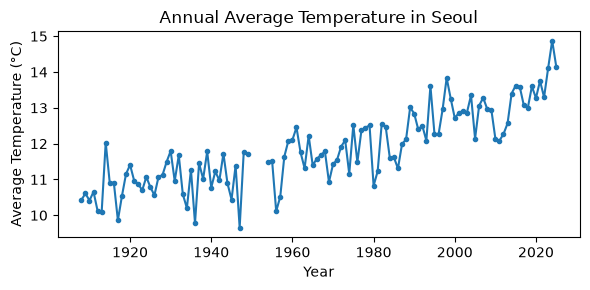

In [ ]:
annual_temp = (df2.groupby("year")["tavg"].mean().reset_index(name="annual_avg_temp"))

# Mark incomplete years as missing
annual_temp.loc[
    annual_temp["year"].isin([1907, 1950, 1951, 1952, 1953, 2026]),
    "annual_avg_temp"
] = np.nan

plt.figure(figsize=(6, 3))
plt.plot(annual_temp["year"], annual_temp["annual_avg_temp"], marker='o', markersize=3)
plt.xlabel("Year")
plt.ylabel("Average Temperature (°C)")
plt.title("Annual Average Temperature in Seoul")
plt.tight_layout()
plt.show()

In [49]:
print(annual_temp.head())
print(annual_temp.tail())
print(annual_temp.dtypes)

   year  annual_avg_temp
0  1907              NaN
1  1908        10.427322
2  1909        10.608767
3  1910        10.412055
4  1911        10.654795
     year  annual_avg_temp
113  2022        13.296164
114  2023        14.109041
115  2024        14.875410
116  2025        14.150411
117  2026              NaN
year                 int64
annual_avg_temp    float64
dtype: object


#### 2.3.2. 월별 기온 패턴 (Monthly temperature pattern)

* 1월은 가장 낮은 기온을, 8월은 가장 높은 기온을 보임.

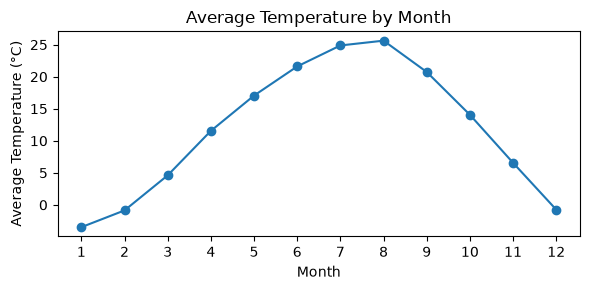

In [50]:
# incomplete 2026 제외: for consistent endpoint (through 2025);
monthly_temp = (df2[df2["year"] <= 2025].groupby("month")["tavg"].mean())  # monthly_temp = df2.groupby("month")["tavg"].mean()

plt.figure(figsize=(6, 3))
plt.plot(monthly_temp.index, monthly_temp.values, marker='o')
plt.xlabel("Month")
plt.ylabel("Average Temperature (°C)")
plt.title("Average Temperature by Month")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

#### 2.3.3. 월별 박스 플롯 (Box plot by month)

* Check seasonal changes.
* Check the median, variability, extreme values for each month.
* 월마다 이상치가 있기는 하나 이는 genuine extreme weather events 일 수도 있으므로 제거하지 않음.

<Figure size 900x300 with 0 Axes>

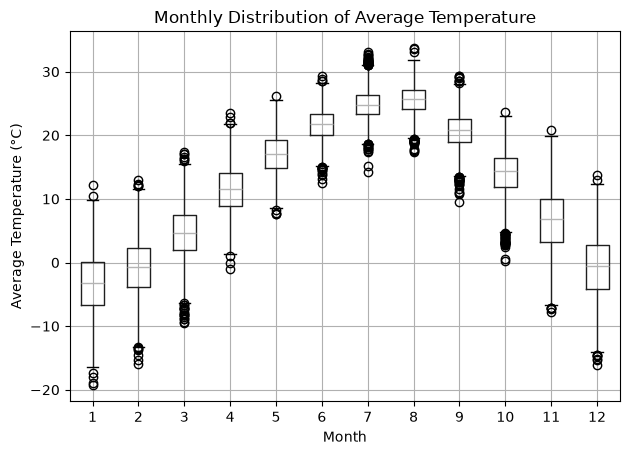

In [51]:
plt.figure(figsize=(9, 3))
df2[df2["year"] <= 2025].boxplot(column="tavg", by="month")   # 2026 제외; 2026 추가: df2.boxplot(column="tavg", by="month")
plt.xlabel("Month")
plt.ylabel("Average Temperature (°C)")
plt.title("Monthly Distribution of Average Temperature")
plt.suptitle("")
plt.tight_layout()
plt.show()